# Предсказание покупки в онлайн-магазине

**Датасет:** 
Online Shoppers Purchasing Intention.

**Задача:**
бинарная классификация: предсказание того, завершится ли пользовательская сессия покупкой.

**Гипотезы:**
1. PageValues окажется одним из наиболее информативных признаков, а его удаление приведёт к заметному снижению Average Precision модели.
2. Из-за дисбаланса классов модель может иметь высокую accuracy, но низкие recall и F1 для класса Revenue=True. Использование class_weight="balanced" повысит recall и F1 для класса покупателей по сравнению с моделью без взвешивания классов, но может снизить precision.
3. Из-за нелинейных зависимостей и сильной асимметрии дерево решений покажет более высокое качество по F1 или Average Precision, чем логистическая регрессия.
4. Применение log1p к сильно скошенным количественным признакам повысит качество логистической регрессии, но почти не повлияет на качество дерева решений.
5. Удаление одного из двух сильно коррелирующих признаков BounceRates и ExitRates почти не ухудшит качество логистической регрессии.
6. Подбор порога классификации на валидационной выборке даст более высокий F1 для класса покупателей, чем стандартный порог 0.5.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [2]:
df = pd.read_csv('online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Количественные признаки: 'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'

Категориальные признаки: 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend'
 
Целевая переменная: 'Revenue'

In [4]:
numeric_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

categorical_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

target_col = "Revenue"

### Проверка на наличие пропущенных значений

In [5]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Пропущенных значений в данном датасете нет.

### Проверка на наличие дубликатов

In [6]:
df.duplicated().sum()

np.int64(125)

In [7]:
duplicates = df[df.duplicated(keep=False)]
print(f"Количество строк, отмеченных как дубликаты: {len(duplicates)}")
display(duplicates.sort_values(by=df.columns.tolist()).head(20))

Количество строк, отмеченных как дубликаты: 201


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


In [8]:
feature_cols = df.columns.drop(target_col)
conflicting_duplicates = (df.groupby(feature_cols.tolist(), dropna=False)[target_col].nunique())
conflicting_duplicates = conflicting_duplicates[conflicting_duplicates > 1]
print("Количество комбинаций признаков с разными значениями Revenue:", len(conflicting_duplicates))

Количество комбинаций признаков с разными значениями Revenue: 0


In [9]:
n_rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_rows_after = len(df)

print(f"Удалено строк: {n_rows_before - n_rows_after}")
print(f"Осталось строк: {n_rows_after}")
print(f"Дубликатов осталось: {df.duplicated().sum()}")

Удалено строк: 125
Осталось строк: 12205
Дубликатов осталось: 0


Дубликаты удалены до разбиения данных чтобы избежать ситуации, что одна и та же строка оказалась в обучающей и тестовой выборке, из-за чего качество модели может быть немного завышено. 

### Описательная статистика

In [10]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,9.000000,94.700000,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,8.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,193.000000,608.942857,1477.154762,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.002899,0.016667,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.014231,0.025000,0.048529,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,1.000000


У всех признаков медиана ниже среднего, 75-ый перцентиль значительно ниже максимума. Это указывает на сильную асимметрию и возможные выбросы. 

Informational, Informational_Duration, PageValues, SpecialDay - медиана и 75-ый перцентиль равны нулю, что указывает на наиболее сильную асимметрию.

### Обзор категориальных признаков

In [11]:
categorical_summary = []

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    categorical_summary.append({
        "Признак": col,
        "Число уникальных значений": df[col].nunique(dropna=False),
        "Наиболее частая категория": counts.index[0],
        "Количество объектов": counts.iloc[0],
        "Доля объектов, %": round(counts.iloc[0] / len(df) * 100, 2)
    })

categorical_summary = pd.DataFrame(categorical_summary)
categorical_summary

,Признак,Число уникальных значений,Наиболее частая категория,Количество объектов,"Доля объектов, %"
0,Month,10,May,3329,27.28
1,OperatingSystems,8,2,6541,53.59
2,Browser,13,2,7883,64.59
3,Region,9,1,4714,38.62
4,TrafficType,20,2,3911,32.04
5,VisitorType,3,Returning_Visitor,10431,85.46
6,Weekend,2,False,9346,76.58


In [12]:
for col in categorical_cols:
    print(f"\nПризнак: {col}")
    counts = df[col].value_counts(dropna=False)
    proportions = df[col].value_counts(normalize=True, dropna=False).mul(100).round(2)
    category_counts = pd.DataFrame({"Количество": counts, "Доля, %": proportions})
    display(category_counts)


Признак: Month


,Количество,"Доля, %"
Month,,
May,3329,27.28
Nov,2982,24.43
Mar,1860,15.24
Dec,1706,13.98
Oct,549,4.50
Sep,448,3.67
Aug,433,3.55
Jul,432,3.54
June,285,2.34



Признак: OperatingSystems


,Количество,"Доля, %"
OperatingSystems,,
2,6541,53.59
1,2549,20.88
3,2530,20.73
4,478,3.92
8,75,0.61
6,19,0.16
7,7,0.06
5,6,0.05



Признак: Browser


...

,Количество,"Доля, %"
TrafficType,,
2,3911,32.04
1,2388,19.57
3,2013,16.49
4,1066,8.73
13,728,5.96
10,450,3.69
6,443,3.63
8,343,2.81
5,260,2.13



Признак: VisitorType


,Количество,"Доля, %"
VisitorType,,
Returning_Visitor,10431,85.46
New_Visitor,1693,13.87
Other,81,0.66



Признак: Weekend


,Количество,"Доля, %"
Weekend,,
False,9346,76.58
True,2859,23.42


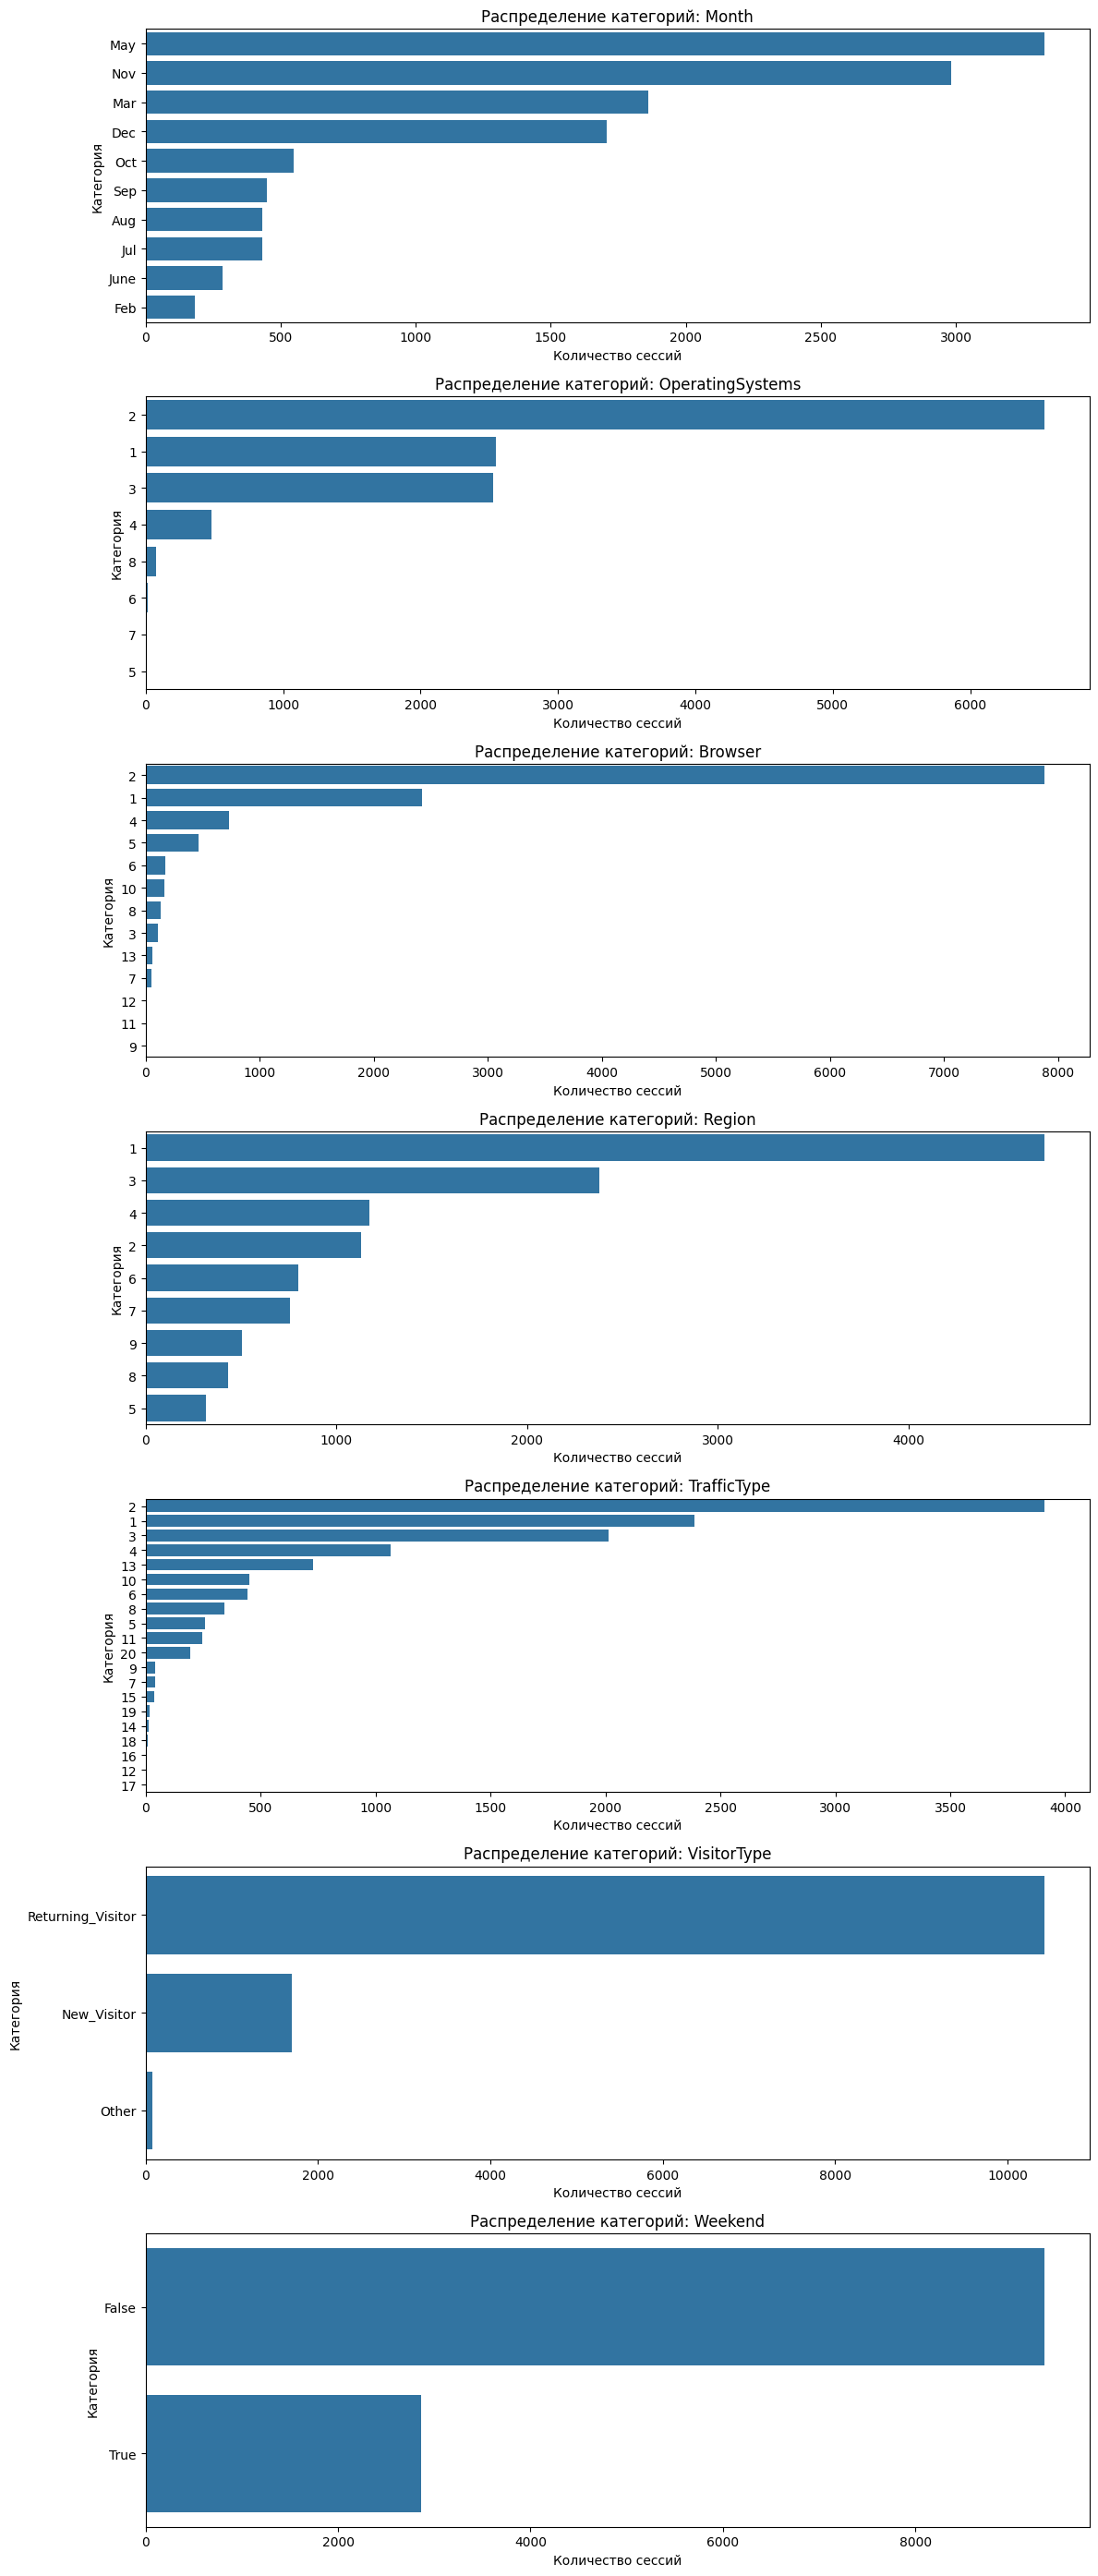

In [13]:
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 4 * len(categorical_cols)))

for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"Распределение категорий: {col}")
    ax.set_xlabel("Количество сессий")
    ax.set_ylabel("Категория")

plt.tight_layout()
plt.show()

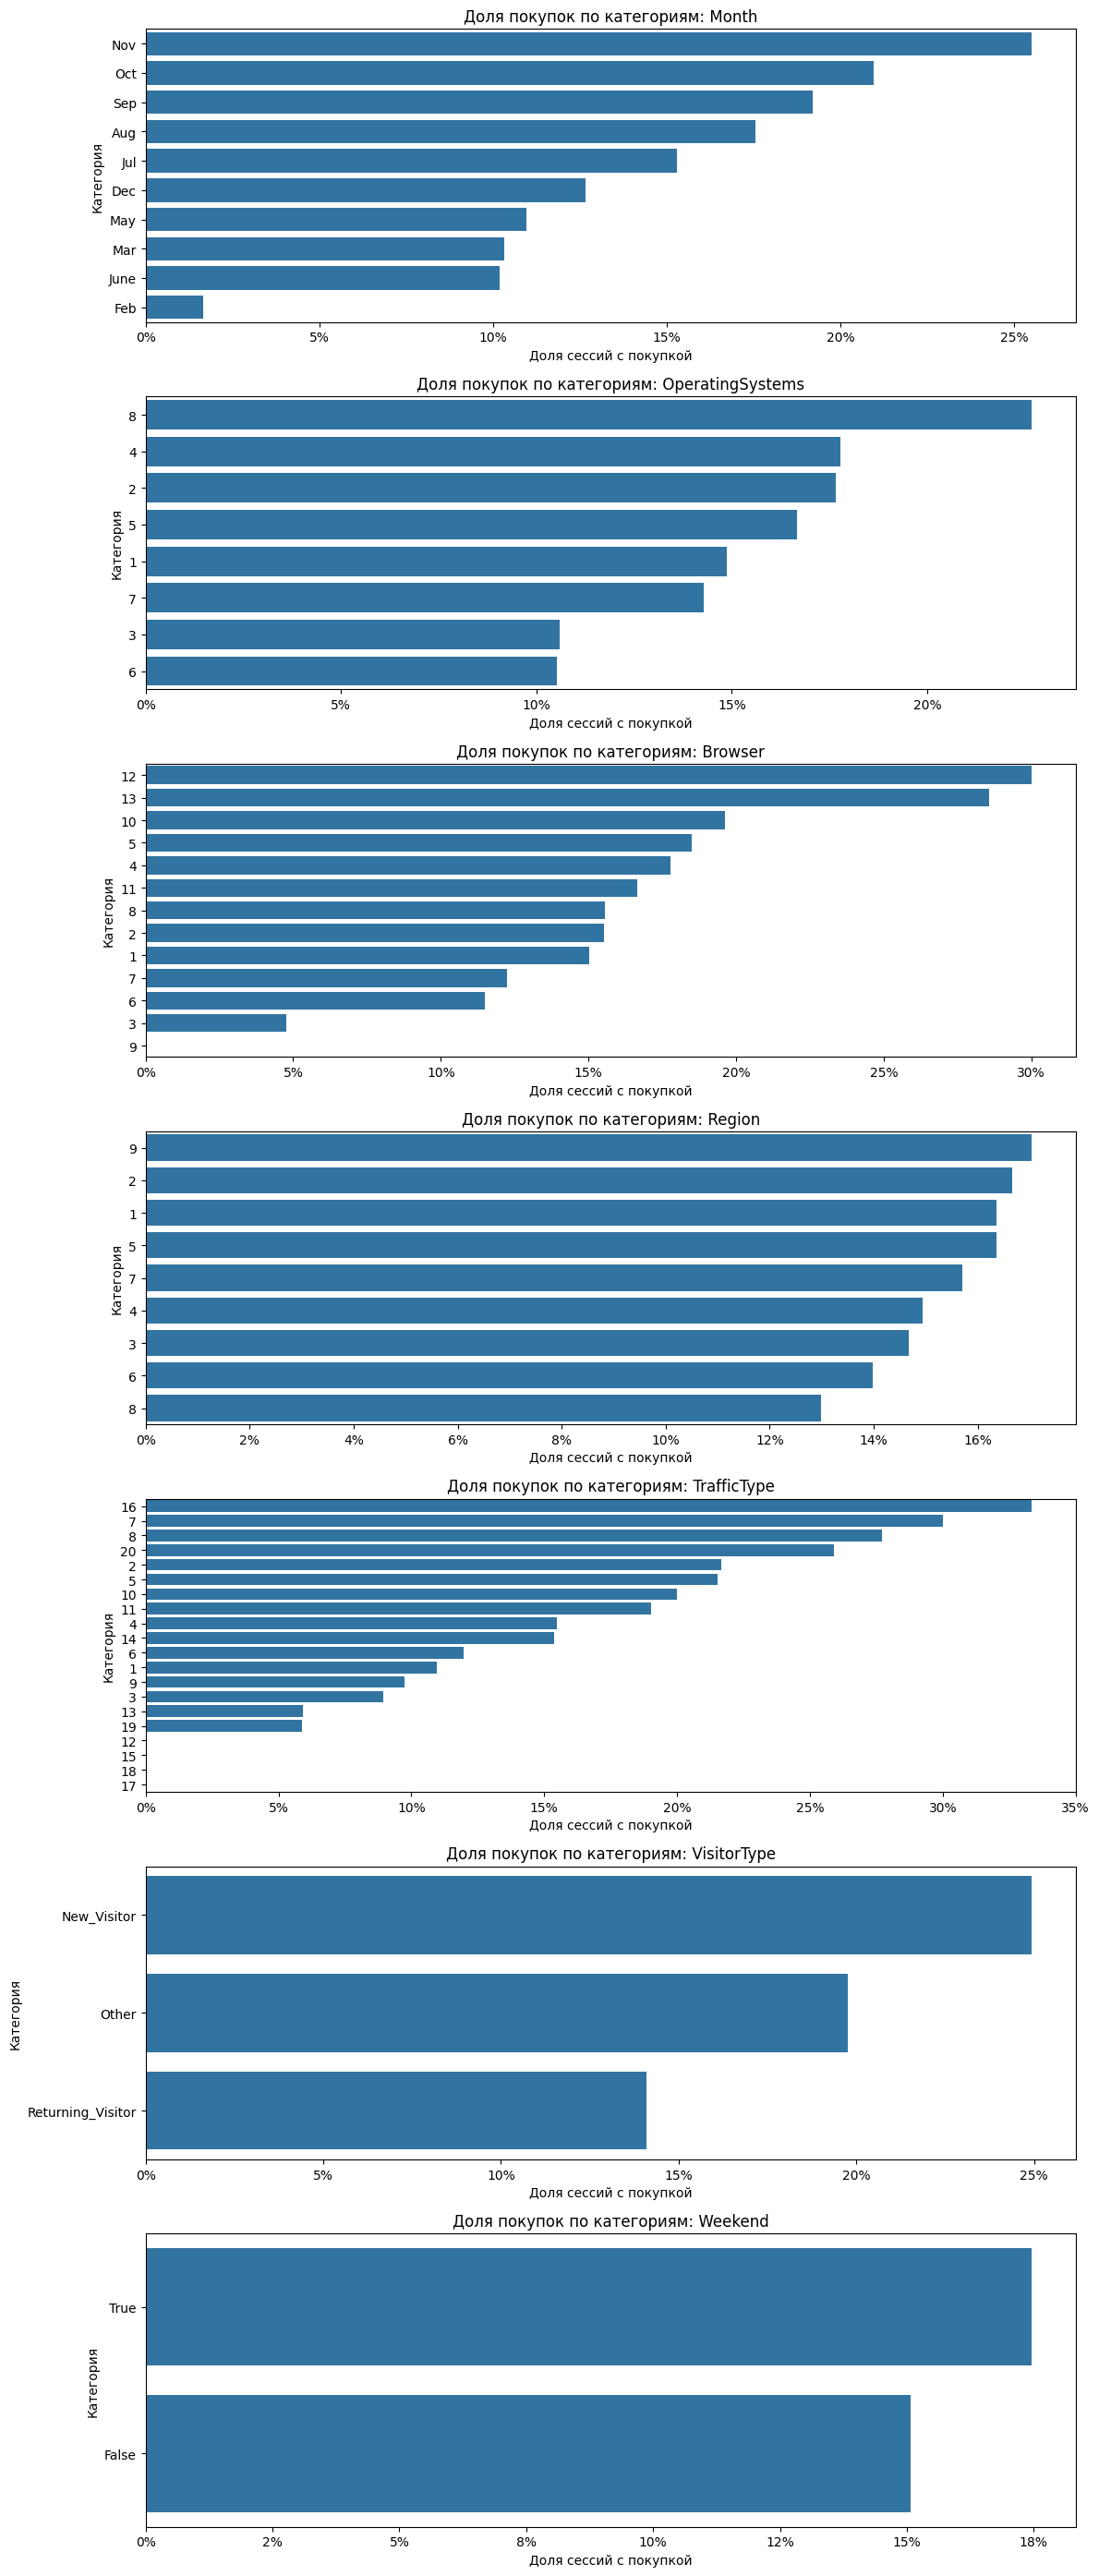

In [14]:
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 4 * len(categorical_cols)))

for ax, col in zip(axes, categorical_cols):
    category_stats = (df.groupby(col, observed=False)[target_col].agg(purchase_rate="mean", count="size").reset_index())
    category_stats["category"] = category_stats[col].astype(str)
    category_stats = category_stats.sort_values("purchase_rate", ascending=False)
    sns.barplot(data=category_stats, x="purchase_rate", y="category", orient="h", errorbar=None, ax=ax)
    ax.set_title(f"Доля покупок по категориям: {col}")
    ax.set_xlabel("Доля сессий с покупкой")
    ax.set_ylabel("Категория")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

plt.tight_layout()
plt.show()

Распределение категорий во многих признаках сильно неравномерно. Поэтому доли покупок необходимо интерпретировать совместно с количеством наблюдений: высокая конверсия в редкой категории может быть результатом малого размера выборки. Наиболее заметные различия в доле покупок наблюдаются для Month, VisitorType и Weekend.

Возвращающиеся посетители составляют около 85% всех сессий. Несмотря на меньшую представленность, у новых посетителей выше доля сессий с покупкой. Категория Other очень редкая - менее 1%, оценка конверсии менее надежна из-за малого числа наблюдений.

Больше всего сессий приходится на май и ноябрь. Наблюдения за январь и апрель отсутствуют. Самая высокая доля сессий с покупкой наблюдается в ноябре, затем в октябре и сентябре, то есть осенью. В мае было больше всего сессий, но доля покупок была заметно ниже, чем в ноябре. Это может указывать на сезонность покупательского поведения.

В выходные сессий заметно меньше, чем в будни, но доля покупок в выходные немного выше: примерно 18% против 15%.

Для признаков OperatingSystems, Browser и TrafficType распределения категорий сильно неравномерны: одна или несколько категорий содержат основную часть наблюдений, а некоторые другие категории представлены единичными сессиями. Поэтому высокая или низкая доля покупок в редких категориях может быть случайной и не отражать устойчивую закономерность. 

### Целевая переменная

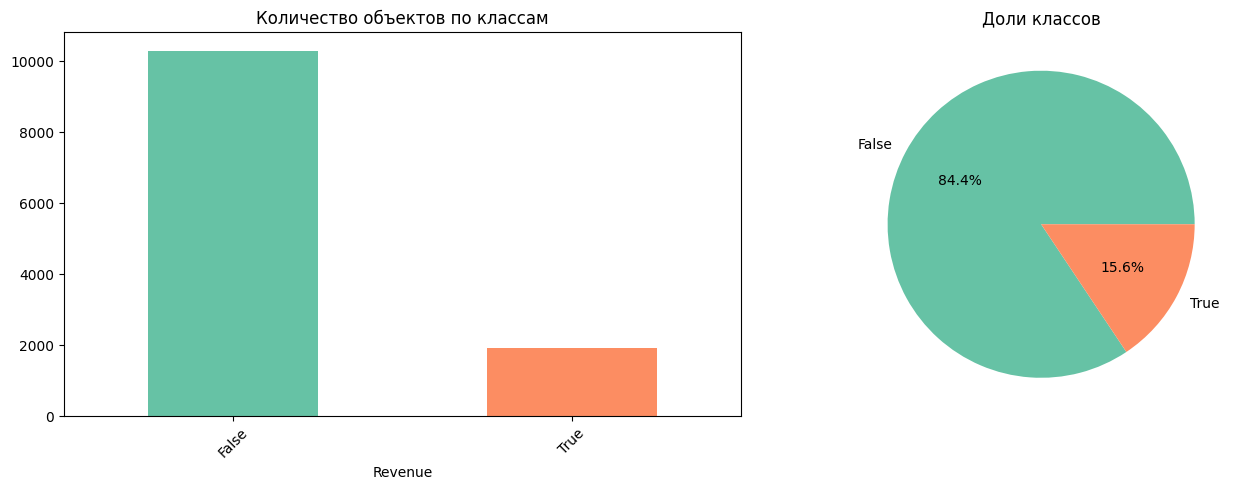

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

Присутствует сильный дисбаланс классов, что естественно для датасета о покупках - большинство сессий не заканчиваются покупкой.

### Распределения количественных признаков

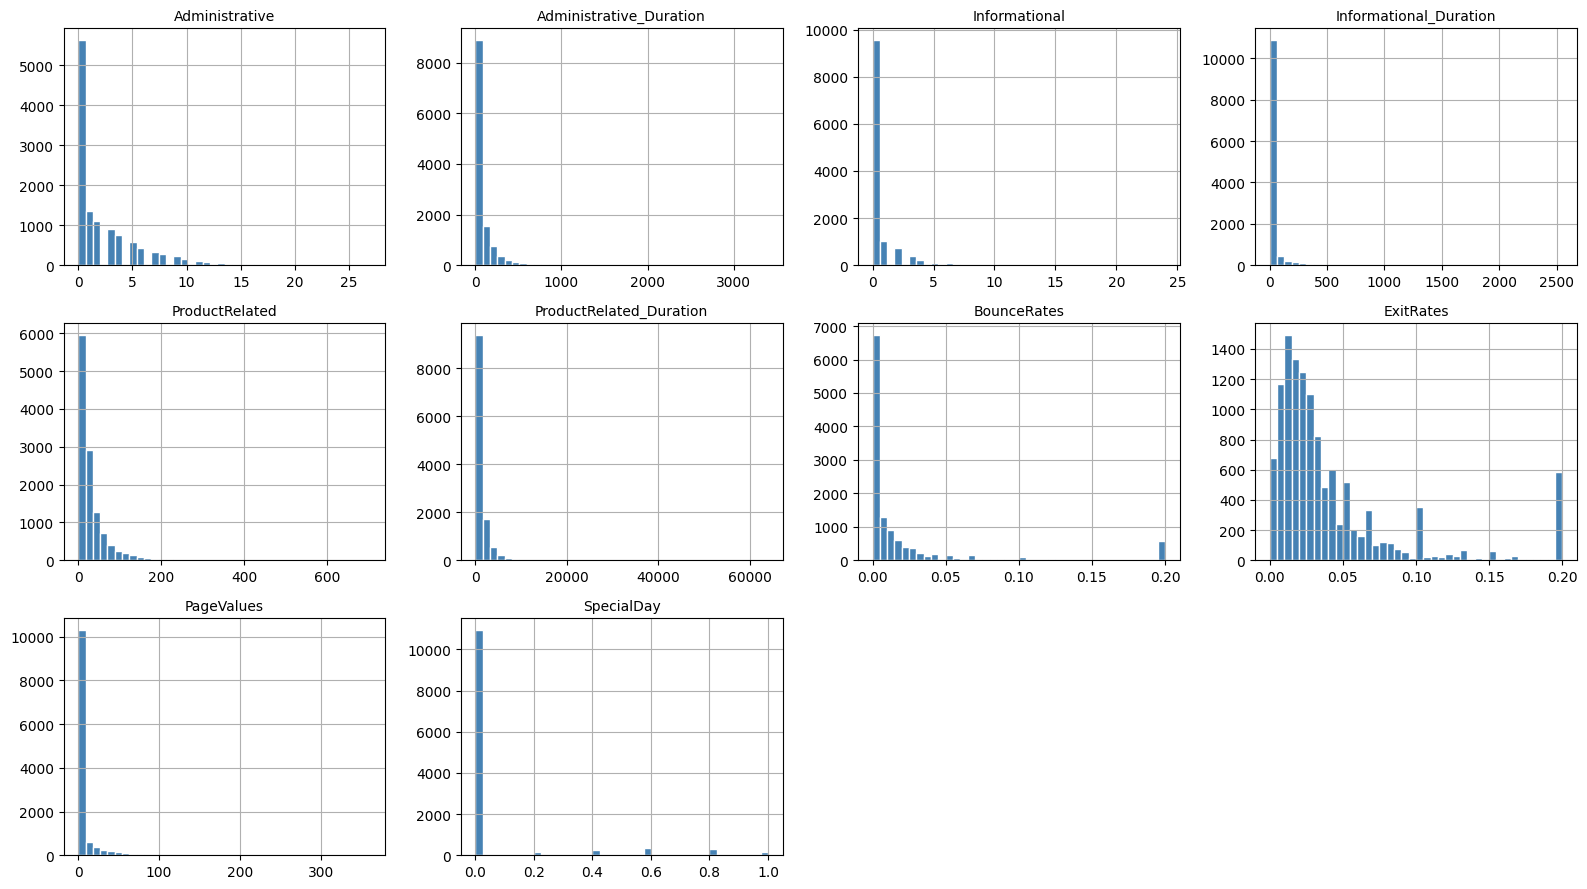

In [16]:
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Большинство количественных имеют выраженную асимметрию. Очень много сессий имеют нулевые значения, т.к. большинство пользователей почти не взаимодействуют с некоторыми разделами сайта. Но также есть те, кто проводят там много времени. Вывод: среднее будет менее информативно, медианы и квартили информативнее. 

BounceRates и ExitRates - в отличие от других количественных признаков, у этих двух заметны скопления у верхней границы 0.2.

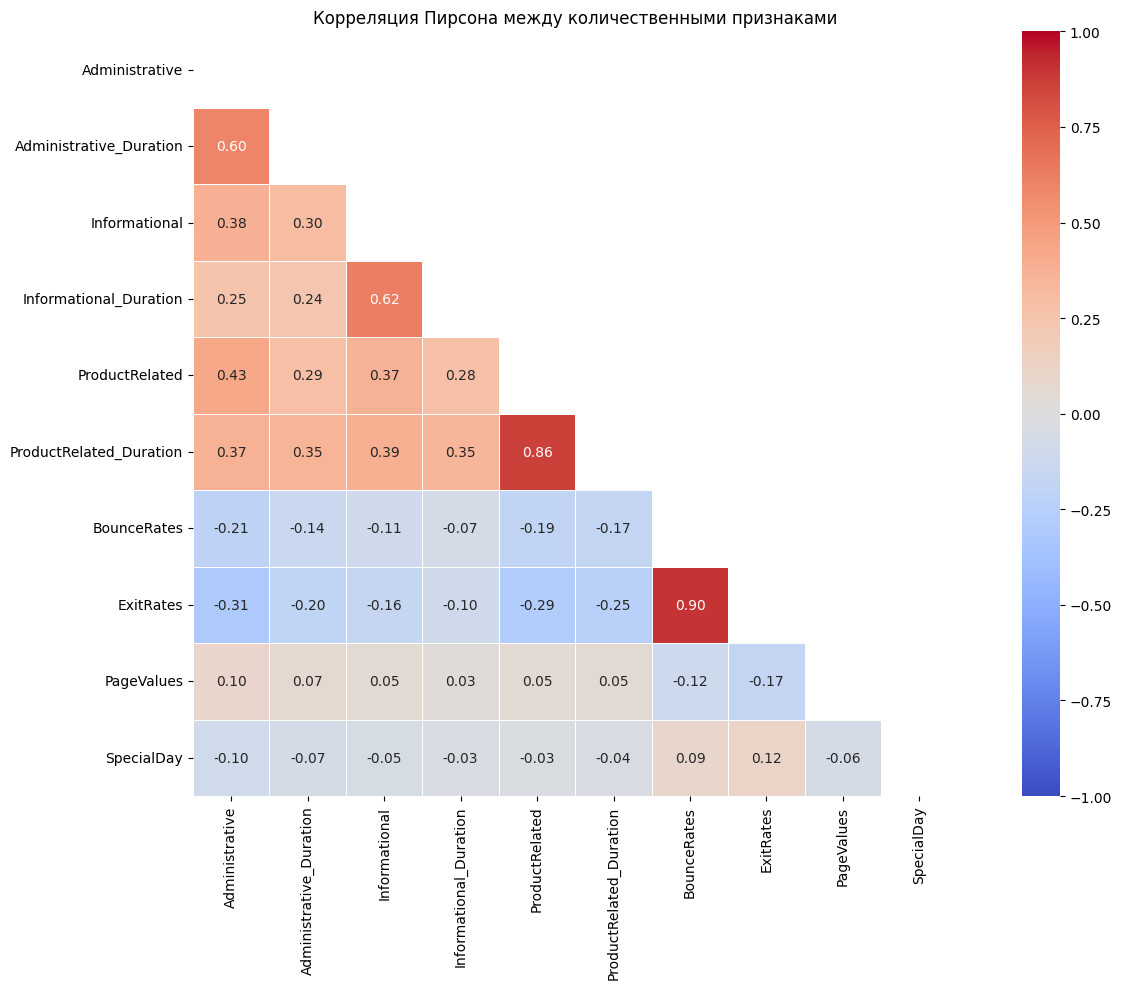

In [17]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Корреляция Пирсона между количественными признаками')
plt.tight_layout()
plt.show()

Поскольку многие признаки имеют большое количество нулевых значений, сильно скошены и могут быть связаны нелинейно, полезно также рассмотреть корреляцию Спирмена.

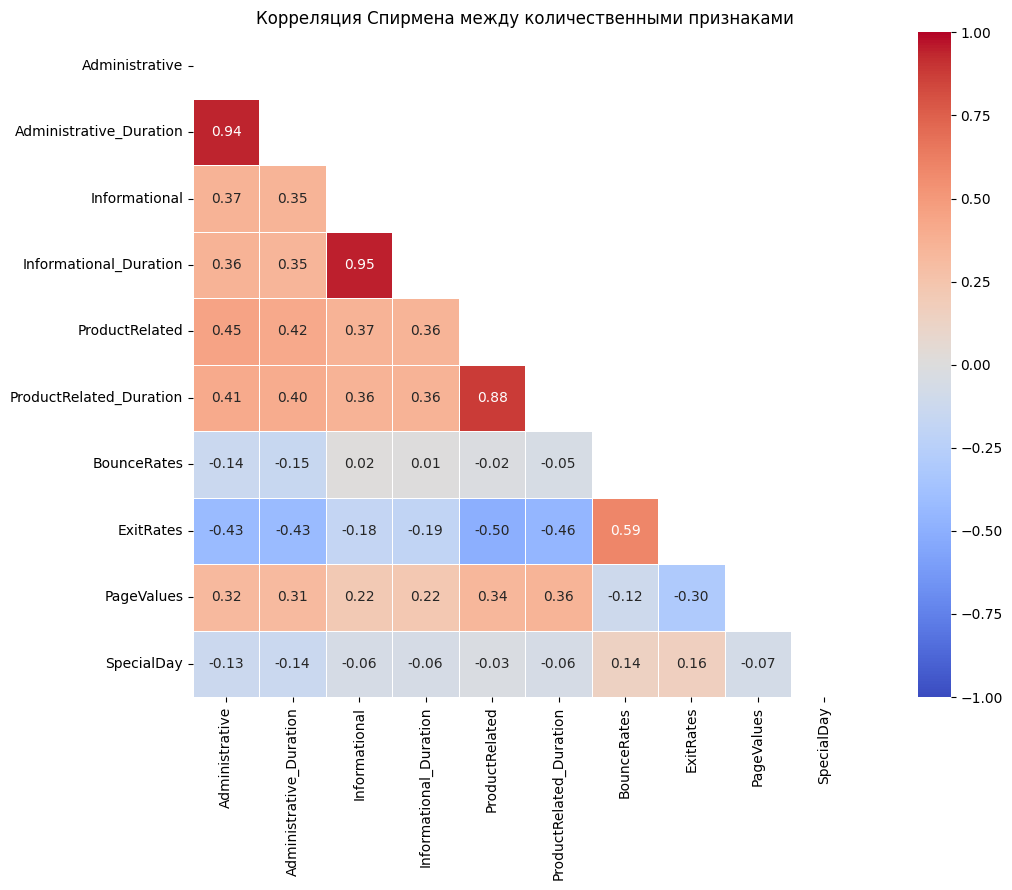

In [18]:
spearman_corr = df[numeric_cols].corr(method="spearman")
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
plt.figure(figsize=(13, 9))
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Корреляция Спирмена между количественными признаками")
plt.tight_layout()
plt.show()

Высокие значения Спирмена означают сильную монотонную связь:
- Administrative и Administrative_Duration: Пирсон около 0.60, но Спирмен около 0.94
- Informational и Informational_Duration: Пирсон около 0.62, но Спирмен около 0.95

Связь не полностью линейная:
- BounceRates и ExitRates: Пирсон около 0.91, Спирмен около 0.60 

Сильная связь в обеих матрицах:
- ProductRelated и ProductRelated_Duration: Пирсон 0.86, Спирмен около 0.88

Эти пары признаков можно использовать для проверки гипотезы 5.

### Boxplot по целевому классу

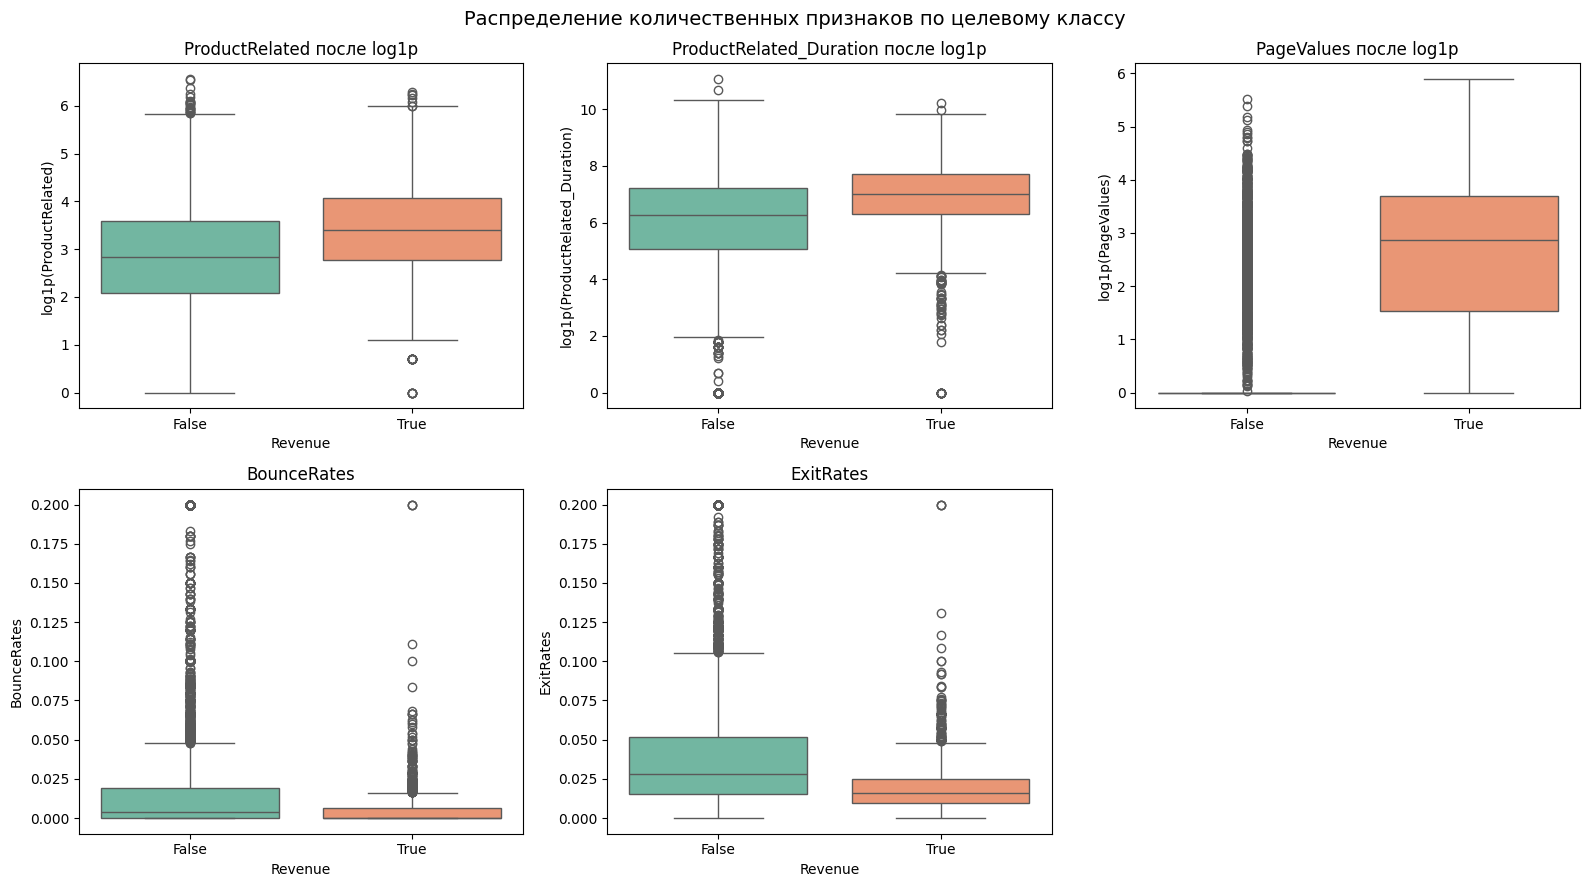

In [19]:
log_cols = ["ProductRelated", "ProductRelated_Duration", "PageValues"]
rate_cols = ["BounceRates", "ExitRates"]

plot_df = df.copy()
plot_df[log_cols] = np.log1p(plot_df[log_cols])
boxplot_cols = log_cols + rate_cols
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, boxplot_cols):
    sns.boxplot(
        data=plot_df,
        x=target_col,
        y=col,
        hue=target_col,
        legend=False,
        palette="Set2",
        ax=ax)
    if col in log_cols:
        ax.set_title(f"{col} после log1p")
        ax.set_ylabel(f"log1p({col})")
    else:
        ax.set_title(col)
        ax.set_ylabel(col)

    ax.set_xlabel("Revenue")

for ax in axes[len(boxplot_cols):]: ax.remove()
plt.suptitle("Распределение количественных признаков по целевому классу", fontsize=14)
plt.tight_layout()
plt.show()

Завершившиеся покупкой сессии характеризуются более высокими значениями ProductRelated, ProductRelated_Duration и особенно PageValues. В то же время значения BounceRates и ExitRates у покупателей в целом ниже. 

PageValues сильно связан с целевой переменной, поэтому этот признак потенциально является одним из наиболее информативных. Но распределения классов пересекаются по всем рассмотренным признакам, следовательно, ни один из них не позволяет определить факт покупки самостоятельно. Значения за пределами усов присутствуют в обоих классах и не удалялись из данных.

In [20]:
special_day_stats = (df.groupby("SpecialDay", as_index=False)[target_col].agg(
    sessions="size", purchases="sum", purchase_rate="mean").sort_values("SpecialDay"))

special_day_stats["purchase_rate_percent"] = (special_day_stats["purchase_rate"] * 100).round(2)

display(special_day_stats[
    [
        "SpecialDay", 
        "sessions", 
        "purchases", 
        "purchase_rate_percent"
    ]
    ]
)

,SpecialDay,sessions,purchases,purchase_rate_percent
0,0.0,10956,1831,16.71
1,0.2,178,14,7.87
2,0.4,243,13,5.35
3,0.6,350,29,8.29
4,0.8,324,11,3.40
5,1.0,154,10,6.49


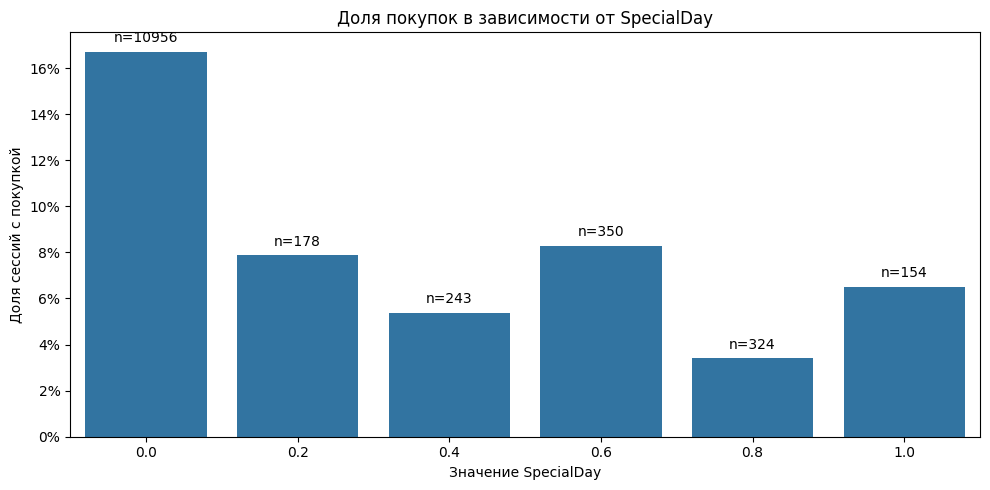

In [21]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=special_day_stats,
    x="SpecialDay",
    y="purchase_rate",
    errorbar=None
)

ax.set_title("Доля покупок в зависимости от SpecialDay")
ax.set_xlabel("Значение SpecialDay")
ax.set_ylabel("Доля сессий с покупкой")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

for patch, sessions in zip(ax.patches, special_day_stats["sessions"]):
    height = patch.get_height()

    ax.annotate(
        f"n={sessions}",
        xy=(patch.get_x() + patch.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

SpecialDay = 0 доминирует в данных и имеет самую высокую долю покупок. Следовательно, близость сессии к специальному дню не связана с повышением конверсии. 

### Итоги EDA

- После удаления полных дубликатов в данных осталось 12205 наблюдений; пропуски отсутствуют.
- Положительный класс существенно реже отрицательного, поэтому accuracy не должна использоваться как единственная метрика.
- Большинство количественных признаков имеют правостороннюю асимметрию, много нулей и значения за пределами усов boxplot.
- Обнаружены сильные связи между количеством страниц и длительностью их просмотра, а также между BounceRates и ExitRates.
- Сессии с покупкой в среднем имеют более высокие ProductRelated, ProductRelated_Duration и PageValues, но более низкие BounceRates и ExitRates.
- Категориальные признаки распределены неравномерно; выводы по редким категориям менее надежны.
- PageValues особенно сильно связан с целевой переменной. Его вклад будет дополнительно проверен удалением признака.

## Обучение моделей

### Подготовка данных и план оценки

Основная метрика - Average Precision т.к. положительный класс встречается значительно реже отрицательного. Дополнительно сравниваются accuracy, precision, recall, F1 и ROC AUC. Порог классификации подбирается только на validation, а test используется один раз для финальной оценки.

In [ ]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, make_scorer, ConfusionMatrixDisplay

from catboost import CatBoostClassifier

In [23]:
X = df.drop(columns=target_col)
y = df[target_col].astype(int)

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42)

In [24]:
preprocessor_linear = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_cols),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

preprocessor_tree = ColumnTransformer([
    ("numeric", "passthrough", numeric_cols),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

In [25]:
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "average_precision": "average_precision",
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Базовые модели

In [26]:
baseline_models = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": Pipeline([
        ("preprocessor", preprocessor_linear),
        ("model", LogisticRegression(max_iter=3000, random_state=42))
    ]),
    "DecisionTree": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "GradientBoosting": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    probabilities = model.predict_proba(X_val)[:, 1]
    predictions = model.predict(X_val)
    baseline_results.append({
        "model": name,
        "accuracy": accuracy_score(y_val, predictions),
        "precision": precision_score(y_val, predictions, zero_division=0),
        "recall": recall_score(y_val, predictions, zero_division=0),
        "f1": f1_score(y_val, predictions, zero_division=0),
        "average_precision": average_precision_score(y_val, probabilities),
        "roc_auc": roc_auc_score(y_val, probabilities)
    })

baseline_results = pd.DataFrame(baseline_results).sort_values("average_precision", ascending=False)
baseline_results

,model,accuracy,precision,recall,f1,average_precision,roc_auc
3,GradientBoosting,0.896764,0.696049,0.601050,0.645070,0.714666,0.915244
1,LogisticRegression,0.881606,0.712963,0.404199,0.515913,0.603665,0.881674
2,DecisionTree,0.849652,0.517413,0.545932,0.531290,0.353345,0.725879
0,DummyClassifier,0.843916,0.000000,0.000000,0.000000,0.156084,0.500000


DummyClassifier получил accuracy 0.844, но его precision, recall и F1 для класса покупателей равны нулю. Это подтверждает, что accuracy не подходит в качестве единственной метрики при дисбалансе. Среди базовых моделей лучший Average Precision показал градиентный бустинг - 0.715.

### Влияние class_weight='balanced'

In [27]:
class_weight_models = {
    "Без взвешивания": Pipeline([
        ("preprocessor", preprocessor_linear),
        ("model", LogisticRegression(max_iter=3000, random_state=42))
    ]),
    "class_weight='balanced'": Pipeline([
        ("preprocessor", preprocessor_linear),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
    ])
}

class_weight_results = []

for name, model in class_weight_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    class_weight_results.append({
        "model": name,
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "average_precision": scores["test_average_precision"].mean()
    })

class_weight_results = pd.DataFrame(class_weight_results)
class_weight_results

,model,precision,recall,f1,average_precision
0,Без взвешивания,0.751606,0.403493,0.524896,0.659349
1,class_weight='balanced',0.538285,0.760699,0.630245,0.668020


Гипотеза 2 подтвердилась. Использование class_weight='balanced' повысило recall с 0.403 до 0.761 и F1 с 0.525 до 0.630, но снизило precision с 0.752 до 0.538. Взвешивание классов помогает находить больше покупателей ценой увеличения числа ложноположительных прогнозов.

### Влияние преобразования log1p

In [28]:
log1p_cols = [
    "Administrative", "Administrative_Duration", "Informational",
    "Informational_Duration", "ProductRelated",
    "ProductRelated_Duration", "PageValues"
]
other_numeric_cols = [col for col in numeric_cols if col not in log1p_cols]

preprocessor_linear_log = ColumnTransformer([
    ("log_numeric", Pipeline([
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler())
    ]), log1p_cols),
    ("other_numeric", StandardScaler(), other_numeric_cols),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

preprocessor_tree_log = ColumnTransformer([
    ("log_numeric", FunctionTransformer(np.log1p, feature_names_out="one-to-one"), log1p_cols),
    ("other_numeric", "passthrough", other_numeric_cols),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

In [29]:
log_models = {
    "LogReg без log1p": Pipeline([
        ("preprocessor", preprocessor_linear),
        ("model", LogisticRegression(max_iter=3000, random_state=42))
    ]),
    "LogReg с log1p": Pipeline([
        ("preprocessor", preprocessor_linear_log),
        ("model", LogisticRegression(max_iter=3000, random_state=42))
    ]),
    "DecisionTree без log1p": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "DecisionTree с log1p": Pipeline([
        ("preprocessor", preprocessor_tree_log),
        ("model", DecisionTreeClassifier(random_state=42))
    ])
}

log_results = []

for name, model in log_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    log_results.append({
        "model": name,
        "f1": scores["test_f1"].mean(),
        "average_precision": scores["test_average_precision"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    })

log_results = pd.DataFrame(log_results)
log_results

,model,f1,average_precision,roc_auc
0,LogReg без log1p,0.524896,0.659349,0.894294
1,LogReg с log1p,0.628687,0.698842,0.915575
2,DecisionTree без log1p,0.573553,0.394374,0.750216
3,DecisionTree с log1p,0.577104,0.397201,0.753693


Гипотеза 4 подтвердилась. После log1p Average Precision логистической регрессии вырос с 0.659 до 0.699, а Average Precision дерева только с 0.394 до 0.397. Логарифмирование помогает линейной модели лучше работать со скошенными распределениями. Для дерева эффект минимален т.к. монотонное преобразование сохраняет порядок значений.

## Подбор гиперпараметров

### Логистическая регрессия

In [30]:
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor_linear_log),
    ("model", LogisticRegression(solver="liblinear", max_iter=5000, random_state=42))
])

logreg_grid = {
    "model__C": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}

logreg_search = GridSearchCV(
    logreg_pipeline, logreg_grid, scoring=scoring, refit="average_precision",
    cv=cv, n_jobs=-1, verbose=1
)
logreg_search.fit(X_train, y_train)

print("Лучший Average Precision:", logreg_search.best_score_)
print("Лучшие параметры:", logreg_search.best_params_)

Fitting 5 folds for each of 44 candidates, totalling 220 fits
Лучший Average Precision: 0.7037623347365459
Лучшие параметры: {'model__C': 0.03, 'model__class_weight': None, 'model__penalty': 'l2'}


### Дерево решений

In [31]:
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_params = {
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [3, 4, 5, 6, 7, 8, 10, 12, 15, None],
    "model__min_samples_split": [2, 5, 10, 20, 40],
    "model__min_samples_leaf": [1, 2, 5, 10, 15, 25, 40],
    "model__max_features": [None, "sqrt", "log2", 0.5, 0.8],
    "model__class_weight": [None, "balanced"]
}

tree_search = RandomizedSearchCV(
    tree_pipeline, tree_params, n_iter=60, scoring=scoring, refit="average_precision",
    cv=cv, n_jobs=-1, verbose=1, random_state=42
)
tree_search.fit(X_train, y_train)

print("Лучший Average Precision:", tree_search.best_score_)
print("Лучшие параметры:", tree_search.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Лучший Average Precision: 0.7212910574743093
Лучшие параметры: {'model__min_samples_split': 40, 'model__min_samples_leaf': 40, 'model__max_features': None, 'model__max_depth': 7, 'model__criterion': 'entropy', 'model__class_weight': 'balanced'}


### Градиентный бустинг

In [32]:
boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", GradientBoostingClassifier(random_state=42))
])

boosting_params = {
    "model__n_estimators": [50, 80, 100, 130, 160, 200, 250, 300, 400],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2],
    "model__max_depth": [1, 2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10, 15, 20, 30],
    "model__subsample": [0.65, 0.75, 0.85, 0.9, 1.0],
    "model__max_features": [None, "sqrt", "log2", 0.5, 0.7, 0.9]
}

boosting_search = RandomizedSearchCV(
    boosting_pipeline, boosting_params, n_iter=60, scoring=scoring,
    refit="average_precision", cv=cv, n_jobs=-1, verbose=1, random_state=42
)
boosting_search.fit(X_train, y_train)

print("Лучший Average Precision:", boosting_search.best_score_)
print("Лучшие параметры:", boosting_search.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Лучший Average Precision: 0.7591799649141032
Лучшие параметры: {'model__subsample': 0.9, 'model__n_estimators': 130, 'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_features': 0.5, 'model__max_depth': 5, 'model__learning_rate': 0.03}


### Случайный лес

In [33]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_params = {
    "model__n_estimators": [200, 300, 500, 700, 1000],
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [None, 6, 8, 10, 12, 16, 20, 30],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8, 12],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
    "model__bootstrap": [True, False]
}

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_params, n_iter=50, scoring=scoring, refit="average_precision",
    cv=cv, n_jobs=-1, verbose=1, random_state=42
)
rf_search.fit(X_train, y_train)

print("Лучший Average Precision:", rf_search.best_score_)
print("Лучшие параметры:", rf_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучший Average Precision: 0.7638389705673119
Лучшие параметры: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 8, 'model__max_features': 0.3, 'model__max_depth': 8, 'model__criterion': 'entropy', 'model__class_weight': None, 'model__bootstrap': True}


### CatBoost

In [34]:
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

for col in categorical_cols:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_val_cat[col] = X_val_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

In [35]:
catboost_model = CatBoostClassifier(
    loss_function="Logloss",
    random_seed=42,
    verbose=0,
    allow_writing_files=False,
    thread_count=1
)

catboost_params = {
    "iterations": [300, 500, 700, 1000, 1300],
    "depth": [4, 5, 6, 7, 8, 9],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15],
    "l2_leaf_reg": [1, 3, 5, 7, 10, 15, 20],
    "random_strength": [0, 0.5, 1, 2, 5],
    "bagging_temperature": [0, 0.5, 1, 2, 5],
    "border_count": [64, 128, 254],
    "auto_class_weights": ["Balanced"]
}

catboost_search = RandomizedSearchCV(
    estimator=catboost_model,
    param_distributions=catboost_params,
    n_iter=40,
    scoring=scoring,
    refit="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

catboost_search.fit(X_train_cat, y_train, cat_features=categorical_cols)

print("Лучший Average Precision:", catboost_search.best_score_)
print("Лучшие параметры:", catboost_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Лучший Average Precision: 0.7630900166259158
Лучшие параметры: {'random_strength': 0, 'learning_rate': 0.01, 'l2_leaf_reg': 15, 'iterations': 700, 'depth': 7, 'border_count': 254, 'bagging_temperature': 0.5, 'auto_class_weights': 'Balanced'}


### Сравнение настроенных моделей на валидации

In [36]:
tuned_models = {
    "LogisticRegression": logreg_search.best_estimator_,
    "DecisionTree": tree_search.best_estimator_,
    "GradientBoosting": boosting_search.best_estimator_,
    "RandomForest": rf_search.best_estimator_
}

validation_results = []

for name, model in tuned_models.items():
    probabilities = model.predict_proba(X_val)[:, 1]
    predictions = model.predict(X_val)
    validation_results.append({
        "model": name,
        "accuracy": accuracy_score(y_val, predictions),
        "precision": precision_score(y_val, predictions, zero_division=0),
        "recall": recall_score(y_val, predictions, zero_division=0),
        "f1": f1_score(y_val, predictions, zero_division=0),
        "average_precision": average_precision_score(y_val, probabilities),
        "roc_auc": roc_auc_score(y_val, probabilities)
    })

In [37]:
catboost_probabilities = catboost_search.best_estimator_.predict_proba(X_val_cat)[:, 1]
catboost_predictions = catboost_search.best_estimator_.predict(X_val_cat).astype(int).ravel()

validation_results.append({
    "model": "CatBoost",
    "accuracy": accuracy_score(y_val, catboost_predictions),
    "precision": precision_score(y_val, catboost_predictions, zero_division=0),
    "recall": recall_score(y_val, catboost_predictions, zero_division=0),
    "f1": f1_score(y_val, catboost_predictions, zero_division=0),
    "average_precision": average_precision_score(y_val, catboost_probabilities),
    "roc_auc": roc_auc_score(y_val, catboost_probabilities)
})

validation_results = pd.DataFrame(validation_results).sort_values("average_precision", ascending=False).reset_index(drop=True)
validation_results

,model,accuracy,precision,recall,f1,average_precision,roc_auc
0,CatBoost,0.855387,0.524138,0.797900,0.632674,0.735744,0.920661
1,RandomForest,0.898812,0.716129,0.582677,0.642547,0.732878,0.919378
2,GradientBoosting,0.894306,0.688073,0.590551,0.635593,0.719953,0.918261
3,DecisionTree,0.836133,0.485226,0.818898,0.609375,0.690514,0.908017
4,LogisticRegression,0.891028,0.693603,0.540682,0.607670,0.635944,0.891935


На валидации лучший Average Precision показал CatBoost - 0.736, затем идут Random Forest - 0.733 и Gradient Boosting - 0.720. CatBoost также имеет высокий recall 0.798, но более низкий precision 0.524.

Гипотеза 3 подтвердилась. Дерево решений превзошло логистическую регрессию по Average Precision: 0.691 против 0.636. Их F1 оказался почти одинаковым: 0.609 и 0.608 соответственно.

## Проверка удаления коррелирующих признаков

In [38]:
preprocessor_without_bounce = ColumnTransformer([
    ("log_numeric", Pipeline([
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler())
    ]), log1p_cols),
    ("other_numeric", StandardScaler(), [col for col in other_numeric_cols if col != "BounceRates"]),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

preprocessor_without_exit = ColumnTransformer([
    ("log_numeric", Pipeline([
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler())
    ]), log1p_cols),
    ("other_numeric", StandardScaler(), [col for col in other_numeric_cols if col != "ExitRates"]),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

correlation_models = {
    "Все признаки": logreg_search.best_estimator_,
    "Без BounceRates": Pipeline([
        ("preprocessor", preprocessor_without_bounce),
        ("model", clone(logreg_search.best_estimator_.named_steps["model"]))
    ]),
    "Без ExitRates": Pipeline([
        ("preprocessor", preprocessor_without_exit),
        ("model", clone(logreg_search.best_estimator_.named_steps["model"]))
    ])
}

correlation_results = []

for name, model in correlation_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    correlation_results.append({
        "model": name,
        "average_precision": scores["test_average_precision"].mean(),
        "average_precision_std": scores["test_average_precision"].std(),
        "f1": scores["test_f1"].mean()
    })

correlation_results = pd.DataFrame(correlation_results)
correlation_results

,model,average_precision,average_precision_std,f1
0,Все признаки,0.703762,0.021422,0.630131
1,Без BounceRates,0.702915,0.021368,0.630760
2,Без ExitRates,0.703304,0.021674,0.626821


Гипотеза 5 подтвердилась. Average Precision составил 0.704 на всех признаках, 0.703 без BounceRates и 0.703 без ExitRates. Удаление одного из коррелирующих признаков почти не повлияло на качество.

## Проверка влияния PageValues

In [39]:
log1p_without_pagevalues = [col for col in log1p_cols if col != "PageValues"]

preprocessor_without_pagevalues = ColumnTransformer([
    ("log_numeric", Pipeline([
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler())
    ]), log1p_without_pagevalues),
    ("other_numeric", StandardScaler(), other_numeric_cols),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

pagevalues_models = {
    "Все признаки": logreg_search.best_estimator_,
    "Без PageValues": Pipeline([
        ("preprocessor", preprocessor_without_pagevalues),
        ("model", clone(logreg_search.best_estimator_.named_steps["model"]))
    ])
}

pagevalues_results = []

for name, model in pagevalues_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    pagevalues_results.append({
        "model": name,
        "average_precision": scores["test_average_precision"].mean(),
        "f1": scores["test_f1"].mean()
    })

pagevalues_results = pd.DataFrame(pagevalues_results)
pagevalues_results

,model,average_precision,f1
0,Все признаки,0.703762,0.630131
1,Без PageValues,0.341548,0.033871


Гипотеза 1 подтвердилась. После удаления PageValues Average Precision снизился с 0.704 до 0.342, а F1 - с 0.630 до 0.034. Этот признак вносит основной вклад в качество логистической регрессии.

## Отбор признаков с помощью SelectKBest

In [40]:
feature_selection_pipeline = Pipeline([
    ("preprocessor", preprocessor_linear_log),
    ("selector", SelectKBest(score_func=f_classif)),
    ("model", clone(logreg_search.best_estimator_.named_steps["model"]))
])

feature_selection_search = GridSearchCV(
    feature_selection_pipeline,
    {"selector__k": [5, 10, 20, 30, 40, 50, "all"]},
    scoring=scoring, refit="average_precision", cv=cv, n_jobs=-1
)
feature_selection_search.fit(X_train, y_train)

print("Лучшее число признаков:", feature_selection_search.best_params_["selector__k"])
print("Лучший Average Precision:", feature_selection_search.best_score_)

Лучшее число признаков: all
Лучший Average Precision: 0.7037623347365459


In [41]:
selection_models = {
    "Без отбора": logreg_search.best_estimator_,
    "SelectKBest": feature_selection_search.best_estimator_
}

selection_results = []

for name, model in selection_models.items():
    probabilities = model.predict_proba(X_val)[:, 1]
    predictions = model.predict(X_val)
    selection_results.append({
        "model": name,
        "f1": f1_score(y_val, predictions, zero_division=0),
        "average_precision": average_precision_score(y_val, probabilities)
    })

selection_results = pd.DataFrame(selection_results)
selection_results

,model,f1,average_precision
0,Без отбора,0.60767,0.635944
1,SelectKBest,0.60767,0.635944


Лучшим вариантом SelectKBest оказался выбор всех признаков. Average Precision и F1 на валидации не изменились, поэтому отбор признаков не улучшил модель.

## Важность признаков

In [42]:
tree_feature_names = tree_search.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
tree_importance = pd.DataFrame({
    "feature": tree_feature_names,
    "importance": tree_search.best_estimator_.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

display(tree_importance.head(15))

,feature,importance
8,numeric__PageValues,0.687322
17,categorical__Month_Nov,0.098070
4,numeric__ProductRelated,0.032862
15,categorical__Month_Mar,0.031915
5,numeric__ProductRelated_Duration,0.031688
16,categorical__Month_May,0.030014
6,numeric__BounceRates,0.023021
1,numeric__Administrative_Duration,0.022519
7,numeric__ExitRates,0.015766
0,numeric__Administrative,0.010541


In [43]:
boosting_feature_names = boosting_search.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
boosting_importance = pd.DataFrame({
    "feature": boosting_feature_names,
    "importance": boosting_search.best_estimator_.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

display(boosting_importance.head(15))

,feature,importance
8,numeric__PageValues,0.676825
7,numeric__ExitRates,0.056387
5,numeric__ProductRelated_Duration,0.042372
4,numeric__ProductRelated,0.040760
6,numeric__BounceRates,0.034251
17,categorical__Month_Nov,0.033692
1,numeric__Administrative_Duration,0.024824
0,numeric__Administrative,0.024175
3,numeric__Informational_Duration,0.010035
71,categorical__VisitorType_Returning_Visitor,0.005623


In [44]:
rf_feature_names = rf_search.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
rf_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_search.best_estimator_.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance.head(15))

,feature,importance
8,numeric__PageValues,0.584468
7,numeric__ExitRates,0.078358
5,numeric__ProductRelated_Duration,0.060161
4,numeric__ProductRelated,0.046194
17,categorical__Month_Nov,0.040104
6,numeric__BounceRates,0.039478
1,numeric__Administrative_Duration,0.027413
0,numeric__Administrative,0.024484
16,categorical__Month_May,0.019083
15,categorical__Month_Mar,0.009928


In [45]:
catboost_importance = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance": catboost_search.best_estimator_.feature_importances_
}).sort_values("importance", ascending=False)

display(catboost_importance.head(15))

,feature,importance
8,PageValues,37.464831
10,Month,30.915982
4,ProductRelated,5.209613
7,ExitRates,4.822401
1,Administrative_Duration,4.187856
14,TrafficType,3.669899
5,ProductRelated_Duration,3.554636
6,BounceRates,2.835481
0,Administrative,2.522809
16,Weekend,1.012274


Наиболее важным признаком с большим отрывом является PageValues. Также стабильно важны ExitRates, BounceRates, количество и длительность просмотра товарных страниц, а также месяц посещения.

## Подбор порога классификации

In [46]:
best_model_name = validation_results.iloc[0]["model"]

if best_model_name == "CatBoost":
    best_model = catboost_search.best_estimator_
    validation_features = X_val_cat
else:
    best_model = tuned_models[best_model_name]
    validation_features = X_val

validation_probabilities = best_model.predict_proba(validation_features)[:, 1]
threshold_results = []

for threshold in np.linspace(0.01, 0.99, 199):
    predictions = (validation_probabilities >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, predictions, zero_division=0),
        "recall": recall_score(y_val, predictions, zero_division=0),
        "f1": f1_score(y_val, predictions, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)
best_threshold = threshold_results.loc[threshold_results["f1"].idxmax(), "threshold"]
threshold_results.loc[threshold_results["f1"].idxmax()]

threshold    0.658384
precision    0.590437
recall       0.745407
f1           0.658933
Name: 131, dtype: float64

In [47]:
default_predictions = (validation_probabilities >= 0.5).astype(int)
best_predictions = (validation_probabilities >= best_threshold).astype(int)

threshold_comparison = pd.DataFrame([
    {
        "threshold": 0.5,
        "precision": precision_score(y_val, default_predictions, zero_division=0),
        "recall": recall_score(y_val, default_predictions, zero_division=0),
        "f1": f1_score(y_val, default_predictions, zero_division=0)
    },
    {
        "threshold": best_threshold,
        "precision": precision_score(y_val, best_predictions, zero_division=0),
        "recall": recall_score(y_val, best_predictions, zero_division=0),
        "f1": f1_score(y_val, best_predictions, zero_division=0)
    }
])
threshold_comparison

,threshold,precision,recall,f1
0,0.500000,0.524138,0.797900,0.632674
1,0.658384,0.590437,0.745407,0.658933


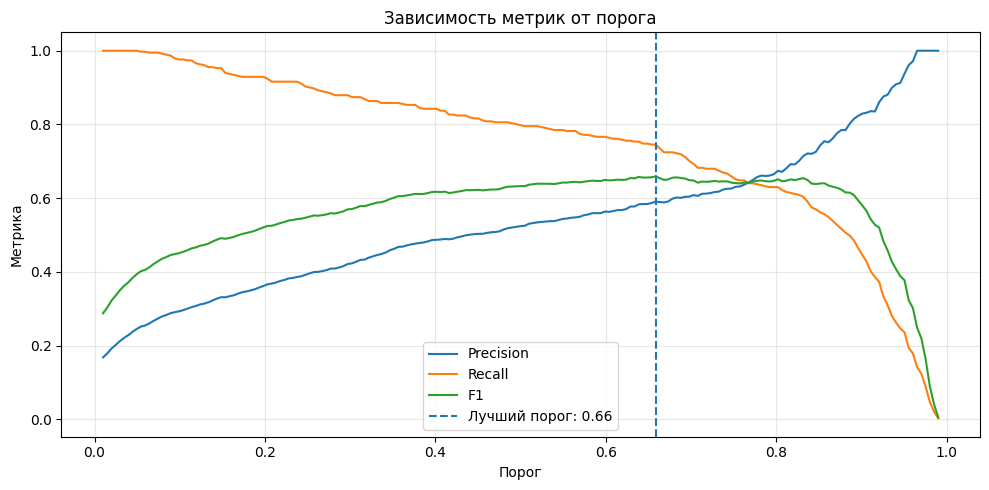

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"Лучший порог: {best_threshold:.2f}")
plt.xlabel("Порог")
plt.ylabel("Метрика")
plt.title("Зависимость метрик от порога")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Гипотеза 6 подтвердилась. На валидации оптимальный порог составил 0.658. По сравнению с порогом 0.5 F1 вырос с 0.633 до 0.659, precision - с 0.524 до 0.590, recall снизился с 0.798 до 0.745.

## Финальная оценка на test

In [49]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

X_train_full_cat = X_train_full.copy()
for col in categorical_cols:
    X_train_full_cat[col] = X_train_full_cat[col].astype(str)

final_estimators = {
    "LogisticRegression": clone(logreg_search.best_estimator_),
    "DecisionTree": clone(tree_search.best_estimator_),
    "GradientBoosting": clone(boosting_search.best_estimator_),
    "RandomForest": clone(rf_search.best_estimator_)
}

test_results = []
fitted_final_models = {}

for name, model in final_estimators.items():
    model.fit(X_train_full, y_train_full)
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = model.predict(X_test)
    fitted_final_models[name] = model
    test_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "average_precision": average_precision_score(y_test, probabilities),
        "roc_auc": roc_auc_score(y_test, probabilities)
    })

test_results = pd.DataFrame(test_results).sort_values("average_precision", ascending=False).reset_index(drop=True)
test_results

,model,accuracy,precision,recall,f1,average_precision,roc_auc
0,RandomForest,0.907825,0.747634,0.620419,0.678112,0.761512,0.935795
1,GradientBoosting,0.905776,0.730303,0.630890,0.676966,0.755238,0.938263
2,DecisionTree,0.852519,0.518152,0.821990,0.635628,0.710040,0.925947
3,LogisticRegression,0.897173,0.709265,0.581152,0.638849,0.696734,0.922694


In [50]:
final_catboost = CatBoostClassifier(
    **catboost_search.best_params_,
    loss_function="Logloss",
    random_seed=42,
    verbose=0,
    allow_writing_files=False,
    thread_count=-1
)

final_catboost.fit(X_train_full_cat, y_train_full, cat_features=categorical_cols)

catboost_probabilities = final_catboost.predict_proba(X_test_cat)[:, 1]
catboost_predictions = final_catboost.predict(X_test_cat).astype(int).ravel()
fitted_final_models["CatBoost"] = final_catboost

catboost_test_row = pd.DataFrame([{
    "model": "CatBoost",
    "accuracy": accuracy_score(y_test, catboost_predictions),
    "precision": precision_score(y_test, catboost_predictions, zero_division=0),
    "recall": recall_score(y_test, catboost_predictions, zero_division=0),
    "f1": f1_score(y_test, catboost_predictions, zero_division=0),
    "average_precision": average_precision_score(y_test, catboost_probabilities),
    "roc_auc": roc_auc_score(y_test, catboost_probabilities)
}])

test_results = pd.concat(
    [test_results, catboost_test_row],
    ignore_index=True
)

test_results = test_results.sort_values(
    "average_precision",
    ascending=False
).reset_index(drop=True)

test_results

,model,accuracy,precision,recall,f1,average_precision,roc_auc
0,RandomForest,0.907825,0.747634,0.620419,0.678112,0.761512,0.935795
1,GradientBoosting,0.905776,0.730303,0.630890,0.676966,0.755238,0.938263
2,CatBoost,0.865219,0.545299,0.835079,0.659772,0.751402,0.935858
3,DecisionTree,0.852519,0.518152,0.821990,0.635628,0.710040,0.925947
4,LogisticRegression,0.897173,0.709265,0.581152,0.638849,0.696734,0.922694


In [51]:
final_best_model = fitted_final_models[best_model_name]
test_features = X_test_cat if best_model_name == "CatBoost" else X_test
test_probabilities = final_best_model.predict_proba(test_features)[:, 1]

test_threshold_results = pd.DataFrame([
    {
        "threshold": 0.5,
        "precision": precision_score(y_test, test_probabilities >= 0.5, zero_division=0),
        "recall": recall_score(y_test, test_probabilities >= 0.5, zero_division=0),
        "f1": f1_score(y_test, test_probabilities >= 0.5, zero_division=0)
    },
    {
        "threshold": best_threshold,
        "precision": precision_score(y_test, test_probabilities >= best_threshold, zero_division=0),
        "recall": recall_score(y_test, test_probabilities >= best_threshold, zero_division=0),
        "f1": f1_score(y_test, test_probabilities >= best_threshold, zero_division=0)
    }
])
test_threshold_results

,threshold,precision,recall,f1
0,0.500000,0.545299,0.835079,0.659772
1,0.658384,0.622030,0.753927,0.681657


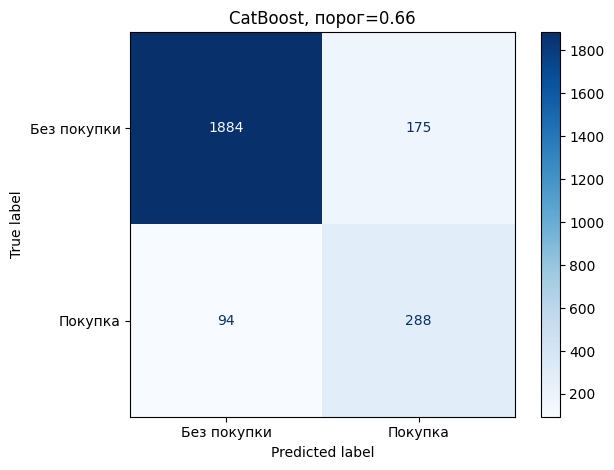

In [52]:
test_predictions = (test_probabilities >= best_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, display_labels=["Без покупки", "Покупка"], cmap="Blues"
)
plt.title(f"{best_model_name}, порог={best_threshold:.2f}")
plt.tight_layout()
plt.show()

## Итоговые выводы

1. Гипотеза 1 подтвердилась: удаление PageValues резко снизило Average Precision и F1 логистической регрессии.
2. Гипотеза 2 подтвердилась: class_weight='balanced' повысил recall и F1, но снизил precision.
3. Гипотеза 3 подтвердилась: дерево решений превзошло логистическую регрессию по Average Precision.
4. Гипотеза 4 подтвердилась: log1p улучшил логистическую регрессию и почти не повлиял на дерево.
5. Гипотеза 5 подтвердилась: удаление BounceRates или ExitRates почти не изменило качество.
6. Гипотеза 6 подтвердилась: подбор порога повысил F1 по сравнению со стандартным порогом 0.5.

На валидации лучший Average Precision показал CatBoost - 0.736. На тестовом множестве лучшим оказался Random Forest: Average Precision = 0.762, ROC AUC = 0.936, F1 = 0.678. Gradient Boosting и CatBoost показали близкие результаты: Average Precision 0.755 и 0.751 соответственно. 

Для CatBoost подобранный порог 0.658 повысил test F1 с 0.660 до 0.682 и precision с 0.545 до 0.622, но снизил recall с 0.835 до 0.754.

Главным признаком оказался PageValues. Также важны месяц посещения, ExitRates, BounceRates, количество и длительность просмотра товарных страниц.